# **Earthquake Prediction Using Machine Learning Techniques**

---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dibuat oleh:
* Riechie (01112210038)
* Ferell Aaron Wirjanto (01112210025)
* Ryuki Ranawidjaja (01112210032)

Untuk memenuhi tugas mata kuliah Kapita Selekta.

# **Data Understanding**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
data_label = pd.read_csv('/content/drive/MyDrive/Kapita Selekta/train_labels.csv')
# data_label = pd.read_csv("C:\\Users\\Riechie Rendy\\OneDrive\\Dokumen\\Kapita Selekta\\Paper 25 Halaman\\train_labels.csv")
data_label.head()

,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3
3,590882,2
4,201944,3


In [ ]:
data_values = pd.read_csv('/content/drive/MyDrive/Kapita Selekta/train_values.csv')
# data_values = pd.read_csv("C:\\Users\\Riechie Rendy\\OneDrive\\Dokumen\\Kapita Selekta\\Paper 25 Halaman\\train_values.csv")
data_values.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = data_values.merge(data_label, on = ['building_id'], how = 'left')
data

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,2
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,3
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,2


In [ ]:
len(data)

260601

In [ ]:
data.shape

(260601, 40)

In [ ]:
data.columns

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_i

In [ ]:
data.dtypes

building_id                                int64
geo_level_1_id                             int64
geo_level_2_id                             int64
geo_level_3_id                             int64
count_floors_pre_eq                        int64
age                                        int64
area_percentage                            int64
height_percentage                          int64
land_surface_condition                    object
foundation_type                           object
roof_type                                 object
ground_floor_type                         object
other_floor_type                          object
position                                  object
plan_configuration                        object
has_superstructure_adobe_mud               int64
has_superstructure_mud_mortar_stone        int64
has_superstructure_stone_flag              int64
has_superstructure_cement_mortar_stone     int64
has_superstructure_mud_mortar_brick        int64
has_superstructure_c

Penjelasan Fitur:
* **geo_level_1_id, geo_level_2_id, geo_level_3_id (type: int)**: geographic region in which building exists, from largest (level 1) to most specific sub-region (level 3). Possible values: level 1: 0-30, level 2: 0-1427, level 3: 0-12567.
* **count_floors_pre_eq (type: int)**: number of floors in the building before the earthquake.
* **age (type: int)**: age of the building in years.
* **area_percentage (type: int)**: normalized area of the building footprint.
* **height_percentage (type: int)**: normalized height of the building footprint.
* **land_surface_condition (type: categorical)**: surface condition of the land where the building was built. Possible values: n, o, t.
* **foundation_type (type: categorical)**: type of foundation used while building. Possible values: h, i, r, u, w.
* **roof_type (type: categorical)**: type of roof used while building. Possible values: n, q, x.
* **ground_floor_type (type: categorical)**: type of the ground floor. Possible values: f, m, v, x, z.
* **other_floor_type (type: categorical)**: type of constructions used in higher than the ground floors (except of roof). Possible values: j, q, s, x.
* **position (type: categorical)**: position of the building. Possible values: j, o, s, t.
* **plan_configuration (type: categorical)**: building plan configuration. Possible values: a, c, d, f, m, n, o, q, s, u.
* **has_superstructure_adobe_mud (type: binary)**: flag variable that indicates if the superstructure was made of Adobe/Mud.
* **has_superstructure_mud_mortar_stone (type: binary)**: flag variable that indicates if the superstructure was made of Mud Mortar - Stone.
* **has_superstructure_stone_flag (type: binary)**: flag variable that indicates if the superstructure was made of Stone.
* **has_superstructure_cement_mortar_stone (type: binary)**: flag variable that indicates if the superstructure was made of Cement Mortar - Stone.
* **has_superstructure_mud_mortar_brick (type: binary)**: flag variable that indicates if the superstructure was made of Mud Mortar - Brick.
* **has_superstructure_cement_mortar_brick (type: binary)**: flag variable that indicates if the superstructure was made of Cement Mortar - Brick.
* **has_superstructure_timber (type: binary)**: flag variable that indicates if the superstructure was made of Timber.
* **has_superstructure_bamboo (type: binary)**: flag variable that indicates if the superstructure was made of Bamboo.
* **has_superstructure_rc_non_engineered (type: binary)**: flag variable that indicates if the superstructure was made of non-engineered reinforced concrete.
* **has_superstructure_rc_engineered (type: binary)**: flag variable that indicates if the superstructure was made of engineered reinforced concrete.
* **has_superstructure_other (type: binary)**: flag variable that indicates if the superstructure was made of any other material.
* **legal_ownership_status (type: categorical)**: legal ownership status of the land where building was built. Possible values: a, r, v, w.
* **count_families (type: int)**: number of families that live in the building.
* **has_secondary_use (type: binary)**: flag variable that indicates if the building was used for any secondary purpose.
* **has_secondary_use_agriculture (type: binary)**: flag variable that indicates if the building was used for agricultural purposes.
* **has_secondary_use_hotel (type: binary)**: flag variable that indicates if the building was used as a hotel.
* **has_secondary_use_rental (type: binary)**: flag variable that indicates if the building was used for rental purposes.
* **has_secondary_use_institution (type: binary)**: flag variable that indicates if the building was used as a location of any institution.
* **has_secondary_use_school (type: binary)**: flag variable that indicates if the building was used as a school.
* **has_secondary_use_industry (type: binary)**: flag variable that indicates if the building was used for industrial purposes.
* **has_secondary_use_health_post (type: binary)**: flag variable that indicates if the building was used as a health post.
* **has_secondary_use_gov_office (type: binary)**: flag variable that indicates if the building was used fas a government office.
* **has_secondary_use_use_police (type: binary)**: flag variable that indicates if the building was used as a police station.
* **has_secondary_use_other (type: binary)**: flag variable that indicates if the building was secondarily used for other purposes.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [ ]:
data.index = data.pop('building_id')
data

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
building_id,,,,,,,,,,,,,,,,,,,,,
802906,6,487,12198,2,30,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
28830,8,900,2812,2,10,8,7,o,r,n,...,0,0,0,0,0,0,0,0,0,2
94947,21,363,8973,2,10,5,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
590882,22,418,10694,2,10,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
201944,11,131,1488,3,30,8,9,t,r,n,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688636,25,1335,1621,1,55,6,3,n,r,n,...,0,0,0,0,0,0,0,0,0,2
669485,17,715,2060,2,0,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
602512,17,51,8163,3,55,6,7,t,r,q,...,0,0,0,0,0,0,0,0,0,3


In [ ]:
data.groupby(['damage_grade']).size()

damage_grade
1     25124
2    148259
3     87218
dtype: int64

# **Data Preprocessing**

---



## Outlier Handling

Before we do any Outlier Handling, we need to inspect wether or not the data training and testing share the same outliers, because if so, then we do not need to do any outlier handling, since the patterns on both datasets will be the same.

In [ ]:
test_data = pd.read_csv('/content/drive/MyDrive/Kapita Selekta/test_values.csv')
test_data

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,300051,17,596,11307,3,20,7,6,t,r,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,t,r,...,1,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,t,r,...,0,0,1,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,t,r,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,310028,4,605,3623,3,70,20,6,t,r,...,1,0,0,0,0,0,0,0,0,0
86864,663567,10,1407,11907,3,25,6,7,n,r,...,0,0,0,0,0,0,0,0,0,0
86865,1049160,22,1136,7712,1,50,3,3,t,r,...,0,0,0,0,0,0,0,0,0,0
86866,442785,6,1041,912,2,5,9,5,t,r,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
def compare_outlier(df1, df2, feature):
  fig, ax = plt.subplots(1,2, figsize = (15, 5))
  sns.boxplot(df1[feature], ax=ax[0])
  ax[0].set_title(f'Training Data Box Plot of {feature}')

  sns.boxplot(df2[feature], ax = ax[1])
  ax[1].set_title(f'Testing Data Box Plot of {feature}')

  training_feature = pd.DataFrame(data[feature].describe())
  training_feature.rename(columns = {f'{feature}': f'Training {feature}'}, inplace = True)
  test_feature = pd.DataFrame(test_data[feature].describe())
  test_feature.rename(columns = {f'{feature}': f'Testing {feature}'}, inplace = True)
  frames = [training_feature, test_feature]
  feature_table = pd.concat(frames, axis = 1)
  return feature_table

,Training age,Testing age
count,260601.000000,86868.000000
mean,26.535029,26.550168
std,73.565937,73.413489
min,0.000000,0.000000
25%,10.000000,10.000000
50%,15.000000,15.000000
75%,30.000000,30.000000
max,995.000000,995.000000


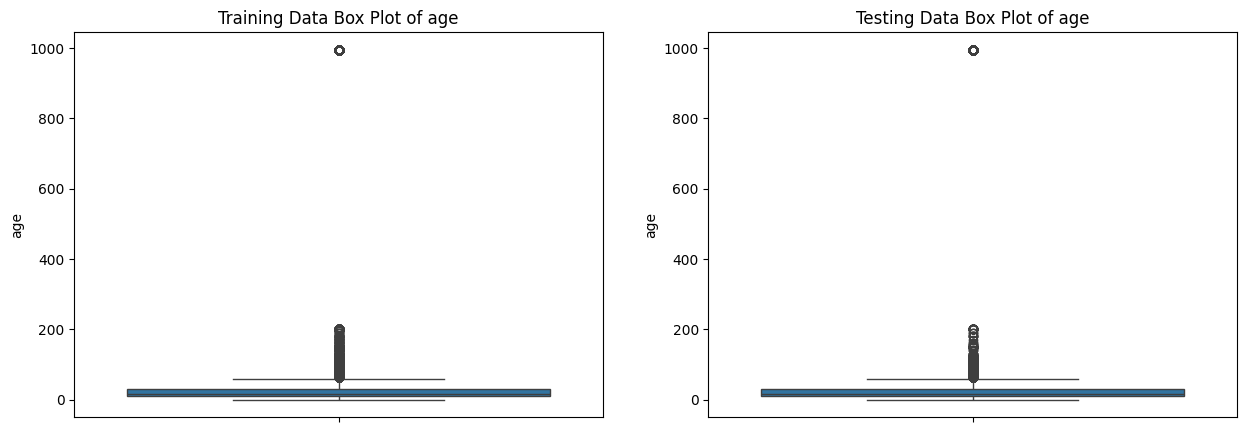

In [ ]:
compare_outlier(data, test_data, 'age')

,Training area_percentage,Testing area_percentage
count,260601.000000,86868.000000
mean,8.018051,8.013906
std,4.392231,4.377899
min,1.000000,1.000000
25%,5.000000,5.000000
50%,7.000000,7.000000
75%,9.000000,9.000000
max,100.000000,92.000000


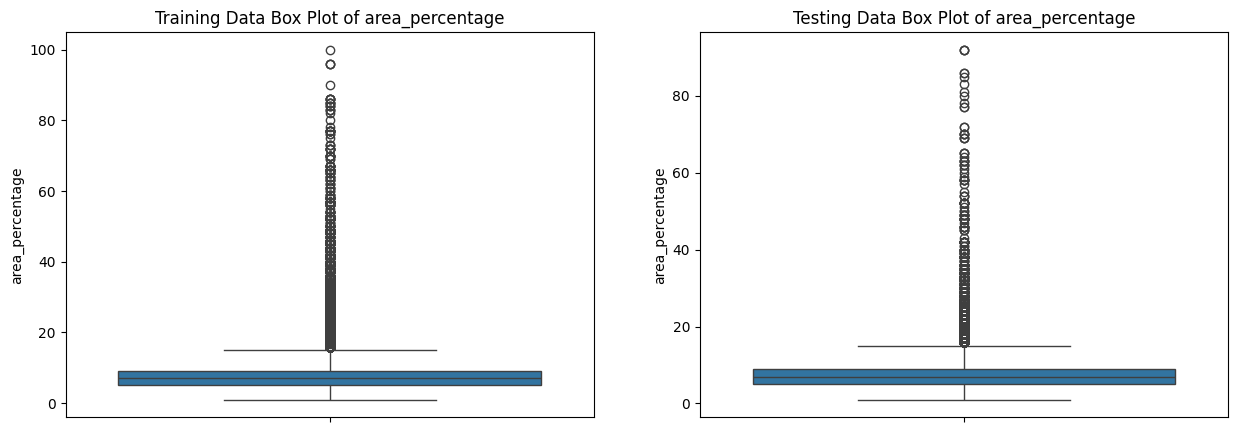

In [ ]:
compare_outlier(data, test_data, 'area_percentage')

,Training height_percentage,Testing height_percentage
count,260601.000000,86868.000000
mean,5.434365,5.436098
std,1.918418,1.906950
min,2.000000,2.000000
25%,4.000000,4.000000
50%,5.000000,5.000000
75%,6.000000,6.000000
max,32.000000,32.000000


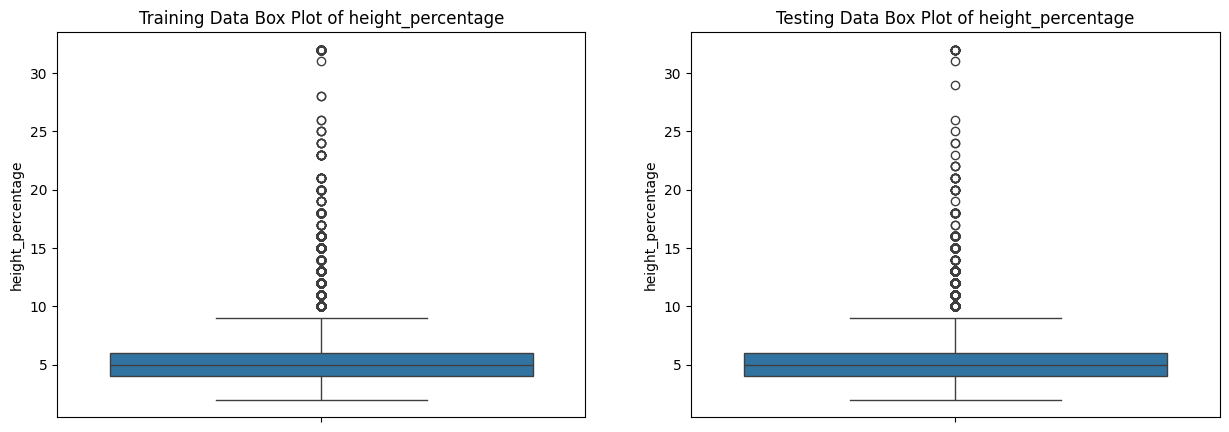

In [ ]:
compare_outlier(data, test_data, 'height_percentage')

As we can see, the outliers in the training data and the testing data are incredibly similiar. Therefore, we have decided to not implement any outlier handling technique for the training data.

## Missing Value and Duplicated Data

In [ ]:
data.isnull().sum().sum()

0

In [ ]:
print(data.duplicated().any())
data.duplicated().sum()

True


12319

In [ ]:
print(data.shape)
data.drop_duplicates(inplace = True)
print(data.shape)

(260601, 39)
(248282, 39)


In [ ]:
data

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
building_id,,,,,,,,,,,,,,,,,,,,,
802906,6,487,12198,2,30,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
28830,8,900,2812,2,10,8,7,o,r,n,...,0,0,0,0,0,0,0,0,0,2
94947,21,363,8973,2,10,5,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
590882,22,418,10694,2,10,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
201944,11,131,1488,3,30,8,9,t,r,n,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688636,25,1335,1621,1,55,6,3,n,r,n,...,0,0,0,0,0,0,0,0,0,2
669485,17,715,2060,2,0,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
602512,17,51,8163,3,55,6,7,t,r,q,...,0,0,0,0,0,0,0,0,0,3


In [ ]:
features = [features for features in data.columns.drop(['damage_grade'])]
print(data[features].duplicated().any())
print(data[features].duplicated().sum())

True
16191


In [ ]:
print(data.shape)
duplicated_data = data.loc[:,features]
duplicated_data.drop_duplicates(keep = 'last', inplace = True)
data_target = data.loc[:,'damage_grade']
data = pd.concat([duplicated_data, data_target], axis = 1).dropna()
print(data.shape)

(260601, 39)
(244410, 39)


In [ ]:
data

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
building_id,,,,,,,,,,,,,,,,,,,,,
802906,6.0,487.0,12198.0,2.0,30.0,6.0,5.0,t,r,n,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
94947,21.0,363.0,8973.0,2.0,10.0,5.0,5.0,t,r,n,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
201944,11.0,131.0,1488.0,3.0,30.0,8.0,9.0,t,r,n,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
333020,8.0,558.0,6089.0,2.0,10.0,9.0,5.0,t,r,n,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
728451,9.0,475.0,12066.0,2.0,25.0,3.0,4.0,n,r,n,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688636,25.0,1335.0,1621.0,1.0,55.0,6.0,3.0,n,r,n,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
669485,17.0,715.0,2060.0,2.0,0.0,6.0,5.0,t,r,n,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
602512,17.0,51.0,8163.0,3.0,55.0,6.0,7.0,t,r,q,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


## Feature Filtering

From observation alone, we can infer that there are a lot of features in the dataset will not have a significant effect on the level of damage taken by a building. We are going to create a new variable to store the dataset without these uncorrelated features, and later on will evaluate wether or not dropping these features actually help the accuracy of the model.

In [ ]:
data_dropped = data.drop(['legal_ownership_status', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental','has_secondary_use_institution', 'has_secondary_use_school','has_secondary_use_industry','has_secondary_use_health_post','has_secondary_use_gov_office','has_secondary_use_use_police','has_secondary_use_other'], axis = 1)
data_dropped

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade
building_id,,,,,,,,,,,,,,,,,,,,,
802906,6,487,12198,2,30,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
28830,8,900,2812,2,10,8,7,o,r,n,...,0,0,0,0,0,0,0,0,0,2
94947,21,363,8973,2,10,5,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
590882,22,418,10694,2,10,6,5,t,r,n,...,0,0,0,0,1,1,0,0,0,2
201944,11,131,1488,3,30,8,9,t,r,n,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688636,25,1335,1621,1,55,6,3,n,r,n,...,0,0,0,0,0,0,0,0,0,2
669485,17,715,2060,2,0,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
602512,17,51,8163,3,55,6,7,t,r,q,...,0,0,0,0,0,0,0,0,0,3


## Encoding Categorical Features

There are 8 categorical features in the original dataset, and 7 categorical features in the modified dataset. In order to feed these data into a machine learning model, first, we have to encode these categorical features into numerical features. There are two most prominent encoding technique used in machine learning, the first one is label encoder, it assigns a number from 0 to n-1 to each element in a feature where n is the number of unique values in the feature, this technique is used if we have ordinal relation within the feature values. The second encoding technique is One Hot Encoding, for each unique values in the feature, it creates a new binary variable (0 or 1). This technique is used when we do not have ordinal relation within the values, or in other word, the categorical feature is a nominal data.

Since we do not know wether the categorical features in this dataset is nominal or ordinal, we will use both techniques and assign them each to a new variable. Later on, we will evaluate which of these two technique is more suitable for this problem.

In [ ]:
Obj_features = [features for features in data.columns if data[features].dtypes == 'O' ]

dropped_obj_features = [features for features in data_dropped.columns if data_dropped[features].dtypes == 'O' ]
dropped_obj_features

['land_surface_condition',
 'foundation_type',
 'roof_type',
 'ground_floor_type',
 'other_floor_type',
 'position',
 'plan_configuration']

In [ ]:
from sklearn.preprocessing import LabelEncoder

Label_encoder = LabelEncoder()
data_dropped_le = data_dropped.copy()
data_le = data.copy()
for features in dropped_obj_features:
    data_dropped_le[features] = Label_encoder.fit_transform(data_dropped_le[features])

for features in Obj_features:
    data_le[features] = Label_encoder.fit_transform(data_le[features])

In [ ]:
data_dropped_ohe = data_dropped.copy()
data_ohe = data.copy()
for features in dropped_obj_features:
    data_dropped_ohe = pd.get_dummies(data_dropped_ohe, columns = [features])

for features in Obj_features:
  data_ohe = pd.get_dummies(data_ohe, columns = [features])

In [ ]:
print(data_le.shape)
print(data_ohe.shape)
print(data_dropped_le.shape)
print(data_dropped_ohe.shape)

(260601, 39)
(260601, 69)
(260601, 26)
(260601, 53)


In [ ]:
data_dropped_le.dtypes

geo_level_1_id                            int64
geo_level_2_id                            int64
geo_level_3_id                            int64
count_floors_pre_eq                       int64
age                                       int64
area_percentage                           int64
height_percentage                         int64
land_surface_condition                    int64
foundation_type                           int64
roof_type                                 int64
ground_floor_type                         int64
other_floor_type                          int64
position                                  int64
plan_configuration                        int64
has_superstructure_adobe_mud              int64
has_superstructure_mud_mortar_stone       int64
has_superstructure_stone_flag             int64
has_superstructure_cement_mortar_stone    int64
has_superstructure_mud_mortar_brick       int64
has_superstructure_cement_mortar_brick    int64
has_superstructure_timber               

## Data Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
data_types = [data_le, data_ohe, data_dropped_le, data_dropped_ohe]

for i in range(0,len(data_types)):
  features = [features for features in data_types[i].columns.drop(['damage_grade'])]
  scaler = MinMaxScaler()
  data_types[i][features] = scaler.fit_transform(data_types[i][features])

data_le.head()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
building_id,,,,,,,,,,,,,,,,,,,,,
802906,0.200000,0.341275,0.970637,0.125,0.030151,0.050505,0.100000,1.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
28830,0.266667,0.630694,0.223761,0.125,0.010050,0.070707,0.166667,0.5,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
94947,0.700000,0.254380,0.714013,0.125,0.010050,0.040404,0.100000,1.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
590882,0.733333,0.292922,0.850959,0.125,0.010050,0.050505,0.100000,1.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
201944,0.366667,0.091801,0.118405,0.250,0.030151,0.070707,0.233333,1.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3


# **Model**

---



## Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score

In [ ]:
rf_score_list = []
for i in range(0, len(data_types)):
  X = data_types[i].drop(['damage_grade'], axis = 1)
  y = data_types[i]['damage_grade']

  train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=42, shuffle = True)

  rf_model = RandomForestClassifier(random_state=42, n_estimators = 100)
  rf_model.fit(train_X, train_y)
  rf_predict = rf_model.predict(test_X)

  rf_score_all = f1_score(test_y, rf_predict, average = 'micro')
  rf_score_list.append(rf_score_all)

In [ ]:
rf_scores = {
    'f1_micro': [rf_score_list[0], rf_score_list[1], rf_score_list[2], rf_score_list[3]]
}

rf_scores_table = pd.DataFrame(rf_scores, index = ['data_le', 'data_ohe', 'data_dropped_le', 'data_dropped_ohe'])
rf_scores_table

,f1_micro
data_le,0.715857
data_ohe,0.710031
data_dropped_le,0.714007
data_dropped_ohe,0.707167


## K-Nearest Neighbor

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

In [ ]:
knn_score_list = []
for i in range(0, len(data_types)):

  X = data_types[i].drop(['damage_grade'], axis = 1)
  y = data_types[i]['damage_grade']

  train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=42, shuffle = True)

  knn_model = KNeighborsClassifier(n_neighbors = 3)
  knn_model.fit(train_X, train_y)
  knn_predict = knn_model.predict(test_X)

  knn_score_all = f1_score(test_y, knn_predict, average = 'micro')
  knn_score_list.append(knn_score_all)

In [ ]:
knn_scores = {
    'f1_micro': [knn_score_list[0], knn_score_list[1], knn_score_list[2], knn_score_list[3]]
}

knn_scores_table = pd.DataFrame(knn_scores, index = ['data_le', 'data_ohe', 'data_dropped_le', 'data_dropped_ohe'])
knn_scores_table

,f1_micro
data_le,0.650885
data_ohe,0.647742
data_dropped_le,0.658920
data_dropped_ohe,0.655696


## Ada Boost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada_score_list = []
for i in range(0, len(data_types)):
  X = data_types[i].drop(['damage_grade'], axis = 1)
  y = data_types[i]['damage_grade']

  train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=42, shuffle = True)

  adaboost_model = AdaBoostClassifier(random_state=42, n_estimators = 100)
  adaboost_model.fit(train_X, train_y)
  adaboost_predict = adaboost_model.predict(test_X)

  adaboost_score_all = f1_score(test_y, adaboost_predict, average = 'micro')
  ada_score_list.append(adaboost_score_all)

In [ ]:
adaboost_scores = {
    'f1_micro': [ada_score_list[0], ada_score_list[1], ada_score_list[2], ada_score_list[3]]
}

adaboost_scores_table = pd.DataFrame(adaboost_scores, index = ['data_le', 'data_ohe', 'data_dropped_le', 'data_dropped_ohe'])
adaboost_scores_table

,f1_micro
data_le,0.651899
data_ohe,0.656629
data_dropped_le,0.652816
data_dropped_ohe,0.655532


 ## LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV

In [ ]:
lgb_score_list = []
for i in range(0, len(data_types)):
  X = data_types[i].drop(['damage_grade'], axis = 1)
  y = data_types[i]['damage_grade']

  encoder = LabelEncoder()
  encoder.fit(y)
  y = encoder.transform(y)

  train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=42, shuffle = True)

  d_train = lgb.Dataset(train_X, label=train_y)
  d_test = lgb.Dataset(test_X, label=test_y)

  params = {
      "max_bin": 512,
      "learning_rate": 0.05,
      "boosting_type": "gbdt",
      "objective": "multiclass",
      "num_classes": 3,
      "metric": "multi_logloss",
      "num_leaves": 10,
      "verbose": -1,
      "min_data": 100,
      "boost_from_average": True,
      "early_stopping_round": 50,
      "num_threads": 6
  }

  lgb_model = lgb.train(
      params,
      d_train,
      10000,
      valid_sets=[d_test],
  )

  lgb_pred = encoder.inverse_transform(np.argmax(lgb_model.predict(test_X), axis = 1))
  test_y = encoder.inverse_transform(test_y)

  f1_score_all = f1_score(test_y, lgb_pred, average = 'micro')
  lgb_score_list.append(f1_score_all)

In [ ]:
lgb_scores = {
    'f1_micro': [lgb_score_list[0], lgb_score_list[1], lgb_score_list[2], lgb_score_list[3]]
}

lgb_scores_table = pd.DataFrame(lgb_scores, index = ['data_le', 'data_ohe', 'data_dropped_le', 'data_dropped_ohe'])
lgb_scores_table

,f1_micro
data_le,0.743596
data_ohe,0.743703
data_dropped_le,0.742368
data_dropped_ohe,0.744194


In [ ]:
X = data_dropped_ohe.drop(['damage_grade'], axis = 1)
y = data_dropped_ohe['damage_grade']

encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=42, shuffle = True)

d_train = lgb.Dataset(train_X, label=train_y)
d_test = lgb.Dataset(test_X, label=test_y)

params = {
    "max_bin": 8192,
    "learning_rate": 0.05,
    "boosting_type": "gbdt",
    "objective": "multiclass",
    "num_classes": 3,
    "metric": "multi_logloss",
    "num_leaves": 10,
    "verbose": -1,
    "min_data": 100,
    "boost_from_average": True,
    "early_stopping_round": 50,
}
lgb_model = lgb.train(
    params,
    d_train,
    10000,
    valid_sets=[d_test],
)

lgb_pred = encoder.inverse_transform(np.argmax(lgb_model.predict(test_X), axis = 1))
test_y = encoder.inverse_transform(test_y)

f1_score_lgb = f1_score(test_y, lgb_pred, average = 'micro')
f1_score_lgb

0.7442403032954213

In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.7/535.7 kB 4.3 MB/s eta 0:00:00


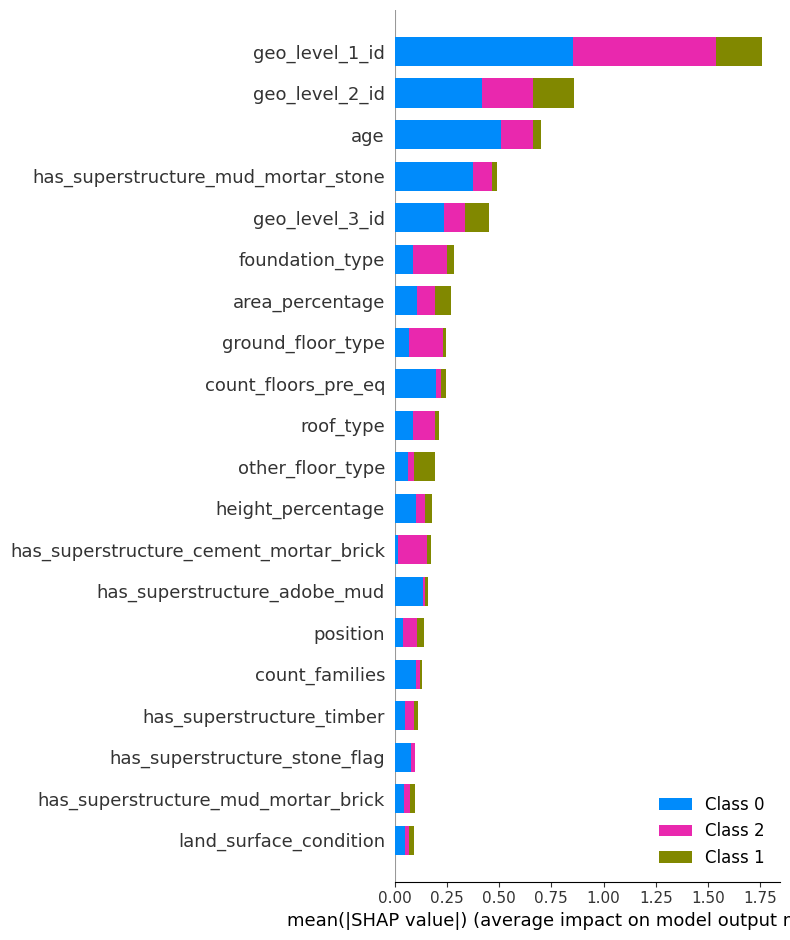

In [ ]:
import shap
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(test_X)
fig: plt.Figure = plt.figure(1)
shap.summary_plot(shap_values, train_X, plot_type="bar", show=True)

# __Evaluation__

In [ ]:
evaluation_table = pd.concat([rf_scores_table.rename(columns = {'f1_micro':'Random Forest'}), knn_scores_table.rename(columns = {'f1_micro':'KNN'})], axis = 1)
evaluation_table = pd.concat([evaluation_table, adaboost_scores_table.rename(columns = {'f1_micro':'AdaBoost'})], axis = 1)
evaluation_table = pd.concat([evaluation_table, lgb_scores_table.rename(columns = {'f1_micro':'lightGBM'})], axis = 1)
evaluation_table

,Random Forest,KNN,AdaBoost,lightGBM
data_le,0.715857,0.650885,0.651899,0.741322
data_ohe,0.710031,0.647742,0.656629,0.740798
data_dropped_le,0.714007,0.658920,0.652816,0.739947
data_dropped_ohe,0.707167,0.655696,0.655532,0.739096


# **Predicting test value using lightGBM**

In [ ]:
test_data = pd.read_csv('/content/drive/MyDrive/Kapita Selekta/test_values.csv')
test_data

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,300051,17,596,11307,3,20,7,6,t,r,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,t,r,...,1,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,t,r,...,0,0,1,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,t,r,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,310028,4,605,3623,3,70,20,6,t,r,...,1,0,0,0,0,0,0,0,0,0
86864,663567,10,1407,11907,3,25,6,7,n,r,...,0,0,0,0,0,0,0,0,0,0
86865,1049160,22,1136,7712,1,50,3,3,t,r,...,0,0,0,0,0,0,0,0,0,0
86866,442785,6,1041,912,2,5,9,5,t,r,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test_data.index = test_data.pop('building_id')
test_data

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
building_id,,,,,,,,,,,,,,,,,,,,,
300051,17,596,11307,3,20,7,6,t,r,n,...,0,0,0,0,0,0,0,0,0,0
99355,6,141,11987,2,25,13,5,t,r,n,...,1,0,0,0,0,0,0,0,0,0
890251,22,19,10044,2,5,4,5,t,r,n,...,0,0,0,0,0,0,0,0,0,0
745817,26,39,633,1,0,19,3,t,r,x,...,0,0,1,0,0,0,0,0,0,0
421793,17,289,7970,3,15,8,7,t,r,q,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310028,4,605,3623,3,70,20,6,t,r,q,...,1,0,0,0,0,0,0,0,0,0
663567,10,1407,11907,3,25,6,7,n,r,n,...,0,0,0,0,0,0,0,0,0,0
1049160,22,1136,7712,1,50,3,3,t,r,n,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
Obj_test_features = [features for features in test_data.columns if test_data[features].dtypes == 'O' ]
Obj_test_features

['land_surface_condition',
 'foundation_type',
 'roof_type',
 'ground_floor_type',
 'other_floor_type',
 'position',
 'plan_configuration',
 'legal_ownership_status']

In [ ]:
Label_encoder = LabelEncoder()
test_data_le = test_data.copy()

for features in Obj_test_features:
    test_data_le[features] = Label_encoder.fit_transform(test_data_le[features])

In [ ]:
test_data_le

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
building_id,,,,,,,,,,,,,,,,,,,,,
300051,17,596,11307,3,20,7,6,2,2,0,...,0,0,0,0,0,0,0,0,0,0
99355,6,141,11987,2,25,13,5,2,2,0,...,1,0,0,0,0,0,0,0,0,0
890251,22,19,10044,2,5,4,5,2,2,0,...,0,0,0,0,0,0,0,0,0,0
745817,26,39,633,1,0,19,3,2,2,2,...,0,0,1,0,0,0,0,0,0,0
421793,17,289,7970,3,15,8,7,2,2,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310028,4,605,3623,3,70,20,6,2,2,1,...,1,0,0,0,0,0,0,0,0,0
663567,10,1407,11907,3,25,6,7,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1049160,22,1136,7712,1,50,3,3,2,2,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test_data_le.dtypes

geo_level_1_id                            int64
geo_level_2_id                            int64
geo_level_3_id                            int64
count_floors_pre_eq                       int64
age                                       int64
area_percentage                           int64
height_percentage                         int64
land_surface_condition                    int64
foundation_type                           int64
roof_type                                 int64
ground_floor_type                         int64
other_floor_type                          int64
position                                  int64
plan_configuration                        int64
has_superstructure_adobe_mud              int64
has_superstructure_mud_mortar_stone       int64
has_superstructure_stone_flag             int64
has_superstructure_cement_mortar_stone    int64
has_superstructure_mud_mortar_brick       int64
has_superstructure_cement_mortar_brick    int64
has_superstructure_timber               

In [ ]:
features = [features for features in test_data_le.columns]
scaler = MinMaxScaler()
test_data_le[features] = scaler.fit_transform(test_data_le[features])

test_data_le.head()

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
building_id,,,,,,,,,,,,,,,,,,,,,
300051,0.566667,0.417659,0.899737,0.285714,0.020101,0.065934,0.133333,1.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99355,0.200000,0.098809,0.953847,0.142857,0.025126,0.131868,0.100000,1.0,0.5,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
890251,0.733333,0.013315,0.799236,0.142857,0.005025,0.032967,0.100000,1.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
745817,0.866667,0.027330,0.050370,0.000000,0.000000,0.197802,0.033333,1.0,0.5,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
421793,0.566667,0.202523,0.634201,0.285714,0.015075,0.076923,0.166667,1.0,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
lgb_test_pred = encoder.inverse_transform(np.argmax(lgb_model.predict(test_data_le), axis = 1))
lgb_test_pred

array([3, 2, 2, ..., 2, 2, 1])

In [ ]:
Submission = pd.DataFrame(lgb_test_pred, columns = ['damage_grade'],index = test_data.index)
Submission

,damage_grade
building_id,
300051,3
99355,2
890251,2
745817,2
421793,3
...,...
310028,2
663567,2
1049160,2


In [ ]:
Submission.to_csv('/content/drive/MyDrive/Kapita Selekta/Submission5.csv')